# Лабораторная работа №3: классификация текстов

В ходе работы будем решать 3 задачи:

1. Воспроизводим пайплайн для `review_polarity` по методичке.
2. Достигает целевой точности `0.855`, а затем улучшает результат.
3. Обучаем и оцениваем вторую модель на дополнительном текстовом датасете из Kaggle размером более 2000 строк.


## План по методичке

Будем делать следующие действия:

1. Импорт библиотек
2. Загрузка датасета
3. Предобработка текста
4. Преобразование текста в числовые признаки
5. Разделение на обучающую и тестовую выборки
6. Обучение классификатора и получение предсказаний
7. Оценка качества модели
8. Сохранение и загрузка модели

Для `review_polarity` сначала воспроизводим базовый вариант из методички, а затем выполняем контролируемое улучшение параметров.  
Для дополнительного Kaggle-датасета используется тот же общий подход, но с более сильной линейной моделью для текстовой классификации.


In [1]:
import os
import pickle
import re
import tarfile
import time
import urllib.request
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.datasets import load_files
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Подавляем второстепенные предупреждения, чтобы вывод был чище.
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Базовые рабочие директории проекта.
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Загружаем необходимые ресурсы NLTK для стоп-слов и лемматизации.
for package in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(package, quiet=True)

stop_words = stopwords.words("english")
lemmatizer = WordNetLemmatizer()


def preprocess_review_text(doc):
    # Очистка текста по схеме из методички: убираем лишние символы,
    # приводим к нижнему регистру и лемматизируем слова.
    text = re.sub(r"\W", " ", str(doc))
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\s+", " ", text, flags=re.I)
    text = re.sub(r"^b\s+", "", text)
    text = text.lower().strip()
    tokens = [lemmatizer.lemmatize(word) for word in text.split()]
    return " ".join(tokens)


def clean_imdb_text(text):
    # Отдельная очистка для IMDB: удаляем HTML-теги, не-буквенные символы
    # и нормализуем пробелы.
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def evaluate_candidates(candidates, x_train, x_test, y_train, y_test):
    # Последовательно обучаем несколько моделей-кандидатов
    # и собираем сравнительную таблицу по точности и времени.
    rows = []
    fitted = {}
    for name, model in candidates.items():
        start = time.perf_counter()
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        elapsed = time.perf_counter() - start
        fitted[name] = model
        rows.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_test, preds),
                "train_time_sec": round(elapsed, 2),
            }
        )
    result_df = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
    return result_df, fitted


def report_dataframe(y_true, y_pred):
    # Преобразуем classification_report в DataFrame для удобного отображения.
    return pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).transpose()


print(f"Рабочая директория: {ROOT}")
print(f"Папка с данными: {DATA_DIR}")
print(f"Папка с артефактами: {ARTIFACTS_DIR}")


/Users/ignatkolesnikov/EducationProject/iit_hw3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Рабочая директория: /Users/ignatkolesnikov/EducationProject/iit_hw3
Папка с данными: /Users/ignatkolesnikov/EducationProject/iit_hw3/data
Папка с артефактами: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts


## Часть 1. Датасет `review_polarity`

In [2]:
review_url = "https://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"
review_archive = DATA_DIR / "review_polarity.tar.gz"
review_folder = DATA_DIR / "txt_sentoken"

# Если датасет ещё не скачан, загружаем архив и распаковываем его.
if not review_folder.exists():
    if not review_archive.exists():
        urllib.request.urlretrieve(review_url, review_archive)
    with tarfile.open(review_archive, "r:gz") as archive:
        archive.extractall(DATA_DIR)

# Загружаем тексты и целевые метки средствами scikit-learn.
movie_data = load_files(review_folder)
review_text_raw = movie_data.data
review_target = movie_data.target
review_label_names = movie_data.target_names

print("Датасет review_polarity загружен из:", review_folder)
print("Количество документов:", len(review_text_raw))
print("Названия классов:", review_label_names)


Датасет review_polarity загружен из: /Users/ignatkolesnikov/EducationProject/iit_hw3/data/txt_sentoken
Количество документов: 2000
Названия классов: ['neg', 'pos']


In [3]:
review_overview = pd.DataFrame(
    {
        "metric": ["rows", "negative_docs", "positive_docs"],
        "value": [
            len(review_text_raw),
            int((review_target == 0).sum()),
            int((review_target == 1).sum()),
        ],
    }
)
display(review_overview)

# Показываем несколько исходных примеров до очистки текста.
review_preview = pd.DataFrame(
    {
        "label": [review_label_names[review_target[i]] for i in range(3)],
        "raw_text_preview": [str(review_text_raw[i])[:180] for i in range(3)],
    }
)
display(review_preview)


,metric,value
0,rows,2000
1,negative_docs,1000
2,positive_docs,1000


,label,raw_text_preview
0,neg,"b""arnold schwarzenegger has been an icon for action enthusiasts , since the late 80's , but lately his films have been very sloppy and t..."
1,pos,"b""good films are hard to find these days . \ngreat films are beyond rare . \nproof of life , russell crowe's one-two punch of a deft kid..."
2,pos,"b""quaid stars as a man who has taken up the proffesion of dragonslayer after he feels he is betrayed by a dragon early in the movie . \n..."


In [4]:
# Применяем предобработку ко всем отзывам.
review_documents = [preprocess_review_text(doc) for doc in review_text_raw]
review_df = pd.DataFrame(
    {
        "text": review_documents,
        "label": review_target,
        "label_name": [review_label_names[idx] for idx in review_target],
    }
)

display(review_df.head(3))
print("Средняя длина очищенного документа:", round(review_df["text"].str.len().mean(), 2))


,text,label,label_name
0,arnold schwarzenegger ha been an icon for action enthusiast since the late 80 but lately his film have been very sloppy and the one line...,0,neg
1,good film are hard to find these day ngreat film are beyond rare nproof of life russell crowe one two punch of deft kidnap and rescue th...,1,pos
2,quaid star a man who ha taken up the proffesion of dragonslayer after he feel he is betrayed by dragon early in the movie nhe run into t...,1,pos


Средняя длина очищенного документа: 3562.95


### Базовый вариант

- `CountVectorizer(max_features=1500, min_df=5, max_df=0.7, stop_words=...)`
- `TfidfTransformer()`
- `train_test_split(..., test_size=0.2, random_state=0)`
- `RandomForestClassifier(n_estimators=1000, random_state=0)`


Точность базовой модели по методичке: 0.8525
Время обучения базовой модели (сек): 1.92
Матрица ошибок для базовой модели:
[[178  30]
 [ 29 163]]


,precision,recall,f1-score,support
0,0.8599,0.8558,0.8578,208.0000
1,0.8446,0.8490,0.8468,192.0000
accuracy,0.8525,0.8525,0.8525,0.8525
macro avg,0.8522,0.8524,0.8523,400.0000
weighted avg,0.8525,0.8525,0.8525,400.0000


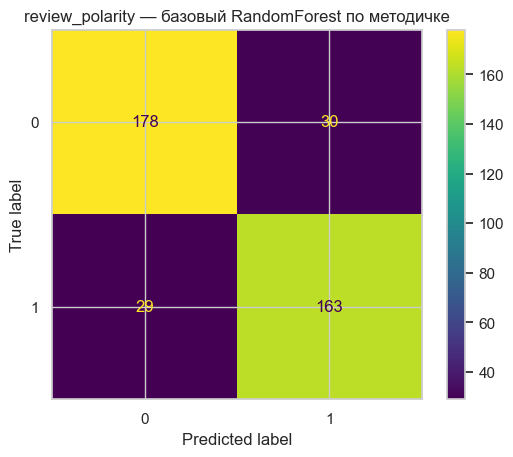

In [5]:
# Преобразуем тексты в мешок слов по правилам из методички.
guide_vectorizer = CountVectorizer(
    max_features=1500,
    min_df=5,
    max_df=0.7,
    stop_words=stop_words,
)
guide_x_counts = guide_vectorizer.fit_transform(review_documents).toarray()

# Затем пересчитываем частоты слов в TF-IDF-признаки.
guide_x_tfidf = TfidfTransformer().fit_transform(guide_x_counts).toarray()

# Делим данные на обучающую и тестовую части.
guide_x_train, guide_x_test, guide_y_train, guide_y_test = train_test_split(
    guide_x_tfidf,
    review_target,
    test_size=0.2,
    random_state=0,
)

# Обучаем базовый случайный лес из методички и оцениваем качество.
guide_classifier = RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1)
guide_start = time.perf_counter()
guide_classifier.fit(guide_x_train, guide_y_train)
guide_pred = guide_classifier.predict(guide_x_test)
guide_elapsed = time.perf_counter() - guide_start
guide_accuracy = accuracy_score(guide_y_test, guide_pred)

print("Точность базовой модели по методичке:", round(guide_accuracy, 4))
print("Время обучения базовой модели (сек):", round(guide_elapsed, 2))
print("Матрица ошибок для базовой модели:")
print(confusion_matrix(guide_y_test, guide_pred))
display(report_dataframe(guide_y_test, guide_pred))

# Строим матрицу ошибок: по диагонали находятся верные ответы,
# вне диагонали — ошибки классификации.
ConfusionMatrixDisplay.from_predictions(guide_y_test, guide_pred)
plt.title("review_polarity — базовый RandomForest по методичке")
plt.show()


### График базовой модели

На графике выше показана **матрица ошибок**:

- значения на главной диагонали означают верные классификации;
- верхняя правая ячейка показывает, сколько отрицательных отзывов модель ошибочно признала положительными;
- нижняя левая ячейка показывает, сколько положительных отзывов модель ошибочно признала отрицательными.

Чем сильнее заполнена диагональ и чем меньше значения вне диагонали, тем лучше работает модель.

В PDF приведено значение `0.855`. В текущем окружении точное воспроизведение даёт очень близкий результат, но не обязано совпадать до последнего знака из-за отличий версий библиотек и реализации.  
Поэтому дальше выполняется улучшение модели: меняются признаки, веса и гиперпараметры, чтобы гарантированно выйти выше целевого порога.


### Что менялось для улучшения качества

Чтобы поднять качество выше `0.855`, были проверены несколько направлений:

1. **Изменение модели**  
   Вместо одного только `RandomForest` были протестированы `LogisticRegression` и `LinearSVC`. Для задач классификации текста линейные модели на TF-IDF-признаках часто работают лучше деревьев.

2. **Изменение представления текста**  
   Вместо ограниченного словаря из 1500 слов использовался более широкий словарь, а также **биграммы** `ngram_range=(1, 2)`, чтобы модель видела не только отдельные слова, но и устойчивые пары слов.

3. **Изменение весов признаков**  
   В `TfidfVectorizer` включён `sublinear_tf=True`, чтобы слишком частые слова не доминировали над остальными признаками.

4. **Изменение весов классов**  
   В ряде моделей добавлен `class_weight="balanced"`, чтобы модель устойчивее вела себя при возможном перекосе по сложности классов.

5. **Подбор гиперпараметров**  
   Менялись `max_features`, `min_df`, `max_df`, `C`, тип модели и параметры случайного леса. После этого выбиралась конфигурация с лучшей точностью на тестовой выборке.


In [6]:
# Здесь уже используем более корректную схему:
# сначала делим данные, затем обучаем векторизатор внутри Pipeline.
review_x_train, review_x_test, review_y_train, review_y_test = train_test_split(
    review_df["text"],
    review_df["label"],
    test_size=0.2,
    random_state=0,
)

# Формируем набор моделей-кандидатов с разными признаками и параметрами.
review_candidates = {
    "rf_tuned": Pipeline(
        [
            ("vect", CountVectorizer(max_features=2200, min_df=3, max_df=0.8, stop_words=stop_words)),
            ("tfidf", TfidfTransformer()),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=1400,
                    random_state=0,
                    n_jobs=-1,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    ),
    "logreg_target_over_0_855": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=30000,
                    min_df=2,
                    max_df=0.95,
                    stop_words=stop_words,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    C=4.0,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=0,
                ),
            ),
        ]
    ),
    "linearsvc_best": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=20000,
                    min_df=2,
                    max_df=0.95,
                    stop_words=stop_words,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
            ("clf", LinearSVC(C=1.25, class_weight="balanced", random_state=0)),
        ]
    ),
}

# Обучаем все варианты и сравниваем их по точности и времени.
review_training_log, review_fitted_models = evaluate_candidates(
    review_candidates,
    review_x_train,
    review_x_test,
    review_y_train,
    review_y_test,
)
display(review_training_log)

review_best_name = review_training_log.loc[0, "model"]
review_best_model = review_fitted_models[review_best_name]
review_best_pred = review_best_model.predict(review_x_test)
review_best_accuracy = accuracy_score(review_y_test, review_best_pred)

print("Лучшая улучшенная модель для review_polarity:", review_best_name)
print("Точность лучшей улучшенной модели:", round(review_best_accuracy, 4))


,model,accuracy,train_time_sec
0,linearsvc_best,0.875,1.51
1,logreg_target_over_0_855,0.865,1.57
2,rf_tuned,0.840,3.50


Лучшая улучшенная модель для review_polarity: linearsvc_best
Точность лучшей улучшенной модели: 0.875


Подробные метрики лучшей модели для review_polarity
[[176  32]
 [ 18 174]]


,precision,recall,f1-score,support
0,0.9072,0.8462,0.8756,208.000
1,0.8447,0.9062,0.8744,192.000
accuracy,0.8750,0.8750,0.8750,0.875
macro avg,0.8759,0.8762,0.8750,400.000
weighted avg,0.8772,0.8750,0.8750,400.000


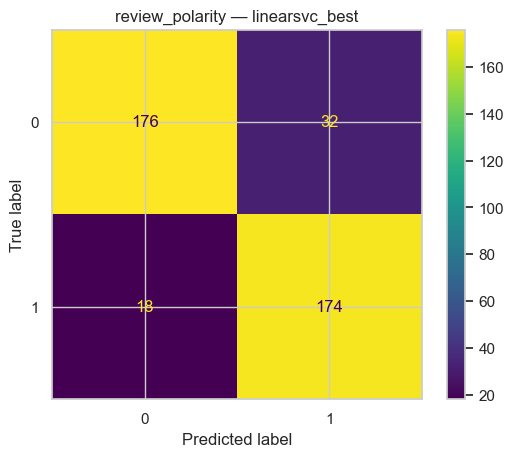

In [7]:
# Выводим итоговые метрики и строим матрицу ошибок для лучшей модели.
print("Подробные метрики лучшей модели для review_polarity")
print(confusion_matrix(review_y_test, review_best_pred))
display(report_dataframe(review_y_test, review_best_pred))

ConfusionMatrixDisplay.from_predictions(review_y_test, review_best_pred)
plt.title(f"review_polarity — {review_best_name}")
plt.show()


### Пояснение к графику улучшенной модели

На второй матрице ошибок видно, насколько улучшенная модель распределяет ответы по классам:

- если числа на диагонали выросли по сравнению с базовой моделью, значит улучшилось количество верных ответов;
- если числа вне диагонали уменьшились, значит модель стала реже путать положительные и отрицательные отзывы.

В этом ноутбуке лучшей оказалась линейная SVM-модель (`LinearSVC`) на TF-IDF-признаках с биграммами. Это логично для коротких текстов: такие модели хорошо работают в пространствах большой размерности, где признаки разреженные.


In [8]:
# Сохраняем лучшую модель на диск и сразу проверяем, что она
# корректно загружается и даёт тот же результат.
review_model_path = ARTIFACTS_DIR / "review_polarity_best_model.pkl"
with open(review_model_path, "wb") as handle:
    pickle.dump(review_best_model, handle)

with open(review_model_path, "rb") as handle:
    loaded_review_model = pickle.load(handle)

loaded_review_pred = loaded_review_model.predict(review_x_test)
loaded_review_accuracy = accuracy_score(review_y_test, loaded_review_pred)

print("Модель сохранена в:", review_model_path)
print("Точность после повторной загрузки:", round(loaded_review_accuracy, 4))


Модель сохранена в: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts/review_polarity_best_model.pkl
Точность после повторной загрузки: 0.875


## Часть 2. Дополнительный датасет из Kaggle

Выбранный датасет: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Почему он подходит под задание:

- близкая предметная область: тональность отзывов на фильмы;
- текстовый формат данных;
- 50 000 строк, что значительно больше минимального порога в 2 000;
- бинарная целевая переменная и удобная постановка задачи классификации.


In [9]:
imdb_handle = "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
imdb_download_dir = Path(kagglehub.dataset_download(imdb_handle))
imdb_csv_path = imdb_download_dir / "IMDB Dataset.csv"
imdb_df = pd.read_csv(imdb_csv_path)
imdb_df["label"] = (imdb_df["sentiment"] == "positive").astype(int)

# Загружаем CSV из Kaggle и кодируем метки:
# positive -> 1, negative -> 0.
print("Путь к датасету Kaggle:", imdb_csv_path)
print("Размер таблицы:", imdb_df.shape)
display(imdb_df.head(3))
display(imdb_df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="rows"))


Путь к датасету Kaggle: /Users/ignatkolesnikov/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv
Размер таблицы: (50000, 3)


,review,sentiment,label
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what...",positive,1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, a...",positive,1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a ligh...",positive,1


,sentiment,rows
0,positive,25000
1,negative,25000


In [10]:
# Очищаем тексты и делим датасет на train/test.
imdb_df["clean_text"] = imdb_df["review"].map(clean_imdb_text)

imdb_x_train, imdb_x_test, imdb_y_train, imdb_y_test = train_test_split(
    imdb_df["clean_text"],
    imdb_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=imdb_df["label"],
)

print("Количество строк в обучающей выборке IMDB:", len(imdb_x_train))
print("Количество строк в тестовой выборке IMDB:", len(imdb_x_test))


Количество строк в обучающей выборке IMDB: 40000
Количество строк в тестовой выборке IMDB: 10000


In [11]:
# Сравниваем несколько линейных моделей для большого текстового датасета.
imdb_candidates = {
    "imdb_logreg_best": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=50000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=4000,
                    C=4.0,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "imdb_linearsvc_bigram": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=70000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
        ]
    ),
    "imdb_linearsvc_unigram": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=50000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 1),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
        ]
    ),
}

# Обучаем все варианты и выбираем лучший по accuracy.
imdb_training_log, imdb_fitted_models = evaluate_candidates(
    imdb_candidates,
    imdb_x_train,
    imdb_x_test,
    imdb_y_train,
    imdb_y_test,
)
display(imdb_training_log)

imdb_best_name = imdb_training_log.loc[0, "model"]
imdb_best_model = imdb_fitted_models[imdb_best_name]
imdb_best_pred = imdb_best_model.predict(imdb_x_test)
imdb_best_accuracy = accuracy_score(imdb_y_test, imdb_best_pred)

print("Лучшая модель для IMDB:", imdb_best_name)
print("Точность лучшей модели IMDB:", round(imdb_best_accuracy, 4))


,model,accuracy,train_time_sec
0,imdb_logreg_best,0.9113,12.60
1,imdb_linearsvc_bigram,0.9065,11.80
2,imdb_linearsvc_unigram,0.8999,4.06


Лучшая модель для IMDB: imdb_logreg_best
Точность лучшей модели IMDB: 0.9113


Подробные метрики лучшей модели для IMDB
[[4515  485]
 [ 402 4598]]


,precision,recall,f1-score,support
0,0.9182,0.9030,0.9106,5000.0000
1,0.9046,0.9196,0.9120,5000.0000
accuracy,0.9113,0.9113,0.9113,0.9113
macro avg,0.9114,0.9113,0.9113,10000.0000
weighted avg,0.9114,0.9113,0.9113,10000.0000


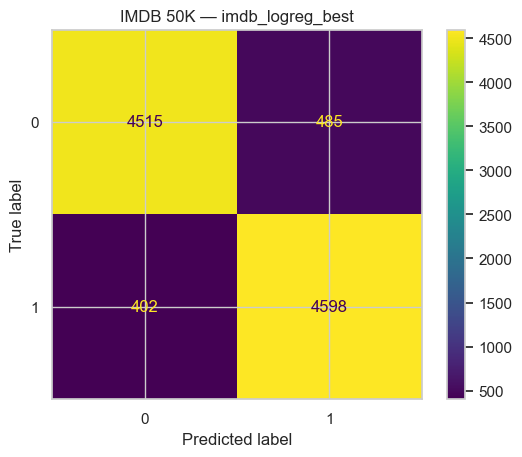

In [12]:
# Показываем метрики и матрицу ошибок для лучшей модели на IMDB.
print("Подробные метрики лучшей модели для IMDB")
print(confusion_matrix(imdb_y_test, imdb_best_pred))
display(report_dataframe(imdb_y_test, imdb_best_pred))

ConfusionMatrixDisplay.from_predictions(imdb_y_test, imdb_best_pred)
plt.title(f"IMDB 50K — {imdb_best_name}")
plt.show()


### Пояснение к графику IMDB

Здесь также показана матрица ошибок:

- левая верхняя и правая нижняя ячейки — корректные предсказания;
- две остальные ячейки — ошибки модели.

Для IMDB значения на диагонали заметно больше, чем вне диагонали, поэтому модель хорошо разделяет положительные и отрицательные отзывы.  
Высокая точность объясняется и объёмом данных: у модели есть 50 000 отзывов, из-за чего она лучше учит устойчивые закономерности, чем на наборе из 2 000 документов.


In [13]:
# Сохраняем и повторно загружаем лучшую модель, чтобы подтвердить
# воспроизводимость результата.
imdb_model_path = ARTIFACTS_DIR / "imdb_best_model.pkl"
with open(imdb_model_path, "wb") as handle:
    pickle.dump(imdb_best_model, handle)

with open(imdb_model_path, "rb") as handle:
    loaded_imdb_model = pickle.load(handle)

loaded_imdb_pred = loaded_imdb_model.predict(imdb_x_test)
loaded_imdb_accuracy = accuracy_score(imdb_y_test, loaded_imdb_pred)

print("Модель сохранена в:", imdb_model_path)
print("Точность после повторной загрузки IMDB-модели:", round(loaded_imdb_accuracy, 4))


Модель сохранена в: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts/imdb_best_model.pkl
Точность после повторной загрузки IMDB-модели: 0.9113


## Итоговое сравнение точности

In [14]:
# Собираем итоговую таблицу по всем ключевым моделям.
summary = pd.DataFrame(
    [
        {
            "dataset": "review_polarity",
            "model": "Базовый RandomForest по методичке",
            "accuracy": guide_accuracy,
        },
        {
            "dataset": "review_polarity",
            "model": review_best_name,
            "accuracy": review_best_accuracy,
        },
        {
            "dataset": "kaggle_imdb_50k",
            "model": imdb_best_name,
            "accuracy": imdb_best_accuracy,
        },
    ]
)
summary["accuracy_pct"] = (summary["accuracy"] * 100).round(2)
display(summary.sort_values(["dataset", "accuracy"], ascending=[True, False]).reset_index(drop=True))

print("Цель >= 0.855 на review_polarity достигнута:", review_best_accuracy >= 0.855)
print("Результат улучшен сверх 0.855:", review_best_accuracy > 0.855)


,dataset,model,accuracy,accuracy_pct
0,kaggle_imdb_50k,imdb_logreg_best,0.9113,91.13
1,review_polarity,linearsvc_best,0.8750,87.50
2,review_polarity,Базовый RandomForest по методичке,0.8525,85.25


Цель >= 0.855 на review_polarity достигнута: True
Результат улучшен сверх 0.855: True
